<a href="https://colab.research.google.com/github/sammatiphugate/sammatiphugate/blob/main/CNN_performance_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Convolutional Neural Network (CNN)

### Importing the libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
tf.__version__

'2.18.0'

In [ ]:
######For Google Colab##########
'''
#Mount Google drive in 'content/drive'
from google.colab import drive
drive.mount('/content/drive')

#Unzip the dtaset in silent mode
! unzip -q '/content/drive/MyDrive/Colab Notebooks/dataset2.zip'
'''

"\n#Mount Google drive in 'content/drive'\nfrom google.colab import drive\ndrive.mount('/content/drive')\n\n#Unzip the dtaset in silent mode\n! unzip -q '/content/drive/MyDrive/Colab Notebooks/dataset2.zip'\n"

## Part 1 - Data Preprocessing

### Preprocessing the Training set

In [ ]:
'''
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=30,           # Slightly more rotation for varied poses
    width_shift_range=0.1,       # Smaller horizontal shift
    height_shift_range=0.1,      # Smaller vertical shift
    shear_range=0.15,            # Gentle shearing
    zoom_range=0.3,              # More zoom to simulate close-ups
    horizontal_flip=True,        # Dogs and cats often face left/right
    brightness_range=[0.8, 1.2], # Simulate lighting changes
    fill_mode='nearest'          # Fill empty pixels after transforms
)
'''


train_datagen = ImageDataGenerator(
    rescale=1. / 255, #By dividing them by 255, you normalize them to the range [0, 1].
    shear_range=0.2, #image can be sheared by up to 20% of its width or height.
    zoom_range=0.2, # image can be zoomed in or out by up to 20%.
    width_shift_range=0.2,  # Randomly shift images horizontally by 20%
    height_shift_range=0.2,  # Randomly shift images vertically by 20%
    rotation_range=20,   # Randomly rotate images by 20 degrees
    horizontal_flip=True
)


training_set = train_datagen.flow_from_directory('dataset/training_set',
                                                 target_size = (64, 64),
                                                 batch_size = 32,
                                                 class_mode = 'binary')


Found 8000 images belonging to 2 classes.


### Preprocessing the Test set

In [ ]:
test_datagen = ImageDataGenerator(rescale = 1./255)
test_set = test_datagen.flow_from_directory('dataset/test_set',
                                            target_size = (64, 64),
                                            batch_size = 32,
                                            class_mode = 'binary')

Found 2000 images belonging to 2 classes.


## Part 2 - Building the CNN

### Initialising the CNN

In [ ]:
'''
cnn = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    #tf.keras.layers.BatchNormalization(), #Batch Normalization (BN) normalizes the inputs of each layer so that they have a mean of 0 and a standard deviation of 1.
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    #tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    tf.keras.layers.Conv2D(256, (3, 3), activation='relu'),
    #tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),  # Helps prevent overfitting
    tf.keras.layers.Dense(1, activation='sigmoid')
])
'''

cnn = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    #tf.keras.layers.BatchNormalization(), #Batch Normalization (BN) normalizes the inputs of each layer so that they have a mean of 0 and a standard deviation of 1.
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Dropout(0.25),  # Helps prevent overfitting


    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    #tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Dropout(0.25),  # Helps prevent overfitting

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    #tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Dropout(0.25),  # Helps prevent overfitting

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),  # Helps prevent overfitting
    tf.keras.layers.Dense(1, activation='sigmoid')
])



C:\Users\Santanu\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Step 1 - Convolution (Input Layer)

- filters=32: Specifies 32 filters, meaning the layer will learn 32 different features from the input.

- kernel_size=3: Uses a 3x3 convolutional filter, which is a common choice for extracting spatial features.

- activation='relu': Applies the ReLU (Rectified Linear Unit) activation function, helping the network to learn nonlinear patterns.

- input_shape=[64, 64, 3]: Defines the input shape for this layer—an image of size 64x64 with 3 color channels (RGB).

### Step 3 - Flattening
- Flatten() transforms the output from 3D to 1D without changing the data, just reshaping it.
- Let’s assume the last Conv/Pooling gives a shape like (32, 32, 64)
- After Flatten() → the output becomes 32 × 32 × 64 = 65536 units (1D vector).

### Step 4 - Full Connection

- units=256: Specifies the number of neurons in this layer. More neurons allow the model to learn complex patterns.

- activation='relu': Applies the ReLU (Rectified Linear Unit) activation function, introducing non-linearity and helping the network detect intricate relationships in the data.

### Step 5 - Output Layer

- units=1: Specifies one neuron, which produces a single numerical output. This is perfect for problems where the goal is to predict a binary outcome (e.g., yes/no, 0/1, cat/dog).

- activation='sigmoid': The sigmoid function squashes the output value between 0 and 1, making it ideal for probability-based predictions.

## Part 3 - Training the CNN

### Compiling the CNN

- optimizer='adam': Uses the Adam optimization algorithm, which is adaptive and helps the model converge efficiently. It adjusts learning rates dynamically based on past gradients.

- loss='binary_crossentropy': Specifies the loss function, ideal for binary classification problems (e.g., classifying between two categories like "dog or cat").

- metrics=['accuracy']: Chooses accuracy as the metric to track model performance during training.

In [ ]:
lr = 0.001  # Your desired learning rate
optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

cnn.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy',tf.keras.metrics.AUC(), tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)


### Training the CNN on the Training set and evaluating it on the Test set

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Callbacks
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_model2.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Train the Model
history = cnn.fit(
    training_set,
    validation_data=test_set,
    epochs=50,
    callbacks=[early_stop, checkpoint],
    verbose=1
)


C:\Users\Santanu\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.5035 - auc: 0.5099 - loss: 0.7083 - precision: 0.4986 - recall: 0.5480
Epoch 1: val_accuracy improved from -inf to 0.61500, saving model to best_model2.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 35s 132ms/step - accuracy: 0.5036 - auc: 0.5100 - loss: 0.7082 - precision: 0.4987 - recall: 0.5481 - val_accuracy: 0.6150 - val_auc: 0.6747 - val_loss: 0.6841 - val_precision: 0.5833 - val_recall: 0.8050
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.5778 - auc: 0.6053 - loss: 0.6763 - precision: 0.5748 - recall: 0.5276
Epoch 2: val_accuracy improved from 0.61500 to 0.62650, saving model to best_model2.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 33s 130ms/step - accuracy: 0.5779 - auc: 0.6054 - loss: 0.6762 - precision: 0.5748 - recall: 0.5278 - val_accuracy: 0.6265 - val_auc: 0.6831 - val_loss: 0.6491 - val_precision: 0.6073 - val_recall: 0.7160
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.5991 - au

## Explanation of Validation Metric Values

### Val Accuracy: `0.8550`
- This means **85.50%** of the total validation samples were classified correctly.
- It includes both true positives and true negatives.
- A strong overall indicator of model performance, but it doesn't tell us how well the model handles class imbalance.

---

### Val Precision: `0.8579`
- Precision = **True Positives / (True Positives + False Positives)**
- A value of **0.8579** means that when the model predicts a positive class, it's correct **85.79%** of the time.
- Example: If the model predicts 100 samples as positive, about **86** of them are truly positive, and **14** are false alarms.

---

### Val Recall: `0.8510`
- Recall = **True Positives / (True Positives + False Negatives)**
- A value of **0.8510** means the model correctly identifies **85.10%** of all actual positive cases.
- Example: If there are 100 actual positive samples in the validation set, the model successfully detects **85** of them, missing **15**.

---

### Val AUC: `0.9330`
- AUC stands for **Area Under the ROC Curve**.
- A value of **0.9330** is excellent—it means there's a **93.30% chance** that the model will rank a randomly chosen positive instance higher than a randomly chosen negative one.
- This reflects strong class separability.

---

### Val Loss: `0.3467`
- This is the **binary cross-entropy loss** on the validation set.
- Lower is better. A value of **0.3467** indicates that the model's predicted probabilities are close to the true labels.
- Compared to training loss (0.4241), this lower value suggests good generalization.

> **Summary**: These numeric values show that your model is performing very well on the validation set—accurate, balanced, and confident in its predictions.



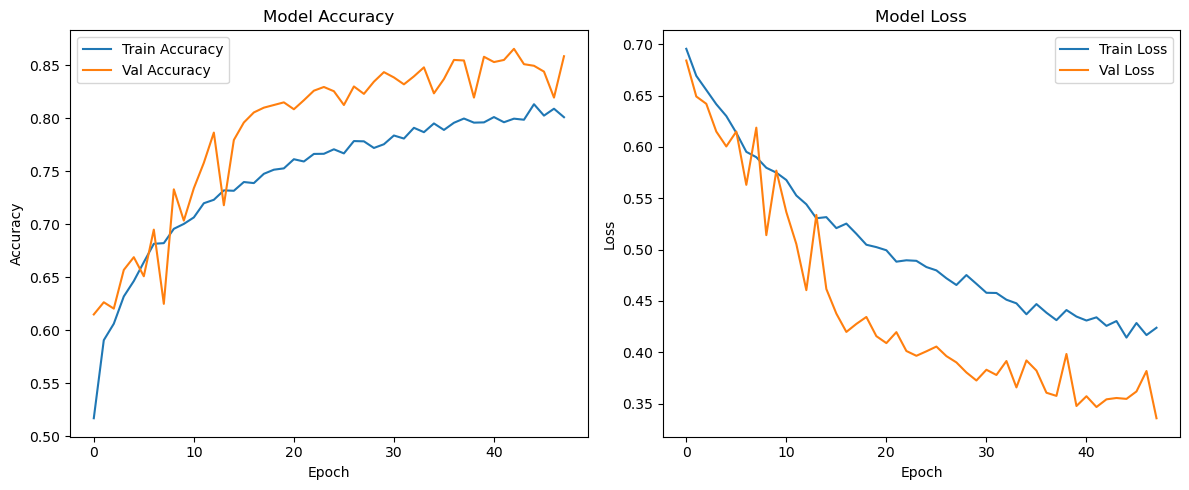

In [ ]:
import matplotlib.pyplot as plt

# Plot Accuracy and Loss
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Part 4 - Making a single prediction

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

from keras.models import load_model
cnn = load_model('best_model2.keras')


test_image = image.load_img('dataset/single_prediction/dog.4040.jpg', target_size = (64, 64))
test_image = image.img_to_array(test_image)
test_image = np.expand_dims(test_image, axis = 0)
result = cnn.predict(test_image)
#print(training_set.class_indices)
if result[0][0] == 1:
  prediction = 'dog'
else:
  prediction = 'cat'

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


In [ ]:
print(prediction)

dog


## Well Done!